# Spiral dataset uses two classes that are tightly intertwined, wrapping around each other multiple times. 

Epoch    0 | Loss: 0.6922 | Accuracy: 48.00%
Epoch  100 | Loss: 0.4699 | Accuracy: 72.00%
Epoch  200 | Loss: 0.2478 | Accuracy: 91.80%
Epoch  300 | Loss: 0.1281 | Accuracy: 99.00%
Epoch  400 | Loss: 0.0553 | Accuracy: 99.50%
Epoch  500 | Loss: 0.0313 | Accuracy: 99.80%
Epoch  600 | Loss: 0.0204 | Accuracy: 99.90%
Epoch  700 | Loss: 0.0148 | Accuracy: 100.00%
Epoch  800 | Loss: 0.0112 | Accuracy: 100.00%
Epoch  900 | Loss: 0.0089 | Accuracy: 100.00%


/var/folders/v0/6kn69j2161z785vv9jl965xw0000gn/T/ipykernel_67550/1455195674.py:91: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


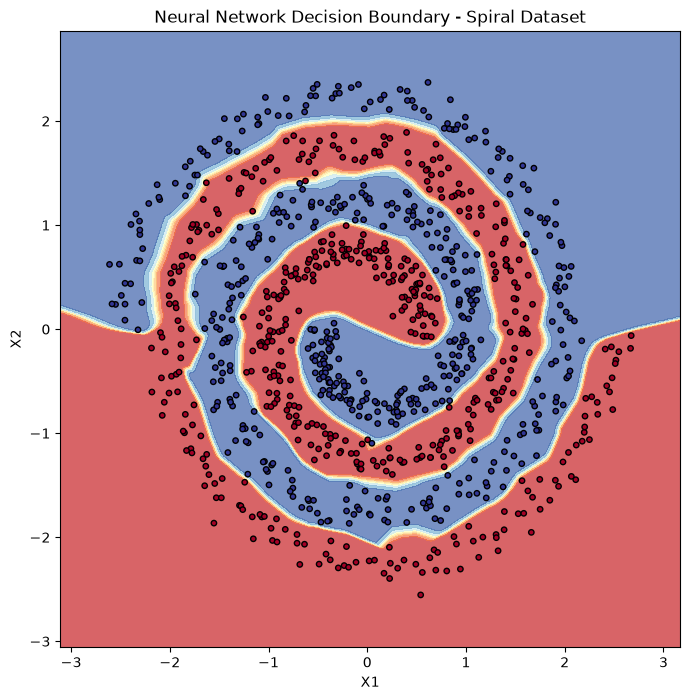

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# --- DATA GENERATION ---
def make_spirals(n_points=1000, noise=0.1):
    n = n_points // 2
    
    t = torch.linspace(0, 1, n)
    theta = t * 4 * np.pi  # Controlling the number of times the spiral loops
    r = t * 2 + 0.5        # Controlling the radius expansion

    # Spiral 1 (Class 0)
    x0 = torch.stack([r * torch.cos(theta), r * torch.sin(theta)], dim=1)
    x0 += torch.randn_like(x0) * noise

    # Spiral 2 (Class 1) - Rotated by pi radians (180 degrees)
    x1 = torch.stack([r * torch.cos(theta + np.pi), r * torch.sin(theta + np.pi)], dim=1)
    x1 += torch.randn_like(x1) * noise

    X = torch.cat([x0, x1], dim=0)
    y = torch.cat([torch.zeros(n), torch.ones(n)]).float() # Floats for BCE loss

    return X, y

X, y = make_spirals()

# --- NEURAL NETWORK MODEL DEFINITION ---
# Because spirals are highly complex, we use a deeper network with 2 hidden layers
class SpiralClassifier(nn.Module):
    def __init__(self):
        super(SpiralClassifier, self).__init__()
        # Input layer: 2 inputs (X1, X2 coordinates) -> 64 hidden neurons
        self.dense1 = nn.Linear(in_features=2, out_features=64)
        self.relu1 = nn.ReLU()
        
        # Hidden Layer 2: 64 hidden neurons -> 64 hidden neurons
        self.dense2 = nn.Linear(in_features=64, out_features=64)
        self.relu2 = nn.ReLU()
        
        # Output layer: 64 hidden neurons -> 1 output prediction (logit)
        self.dense3 = nn.Linear(in_features=64, out_features=1)
        
    def forward(self, x):
        # Forward pass execution through layers and ReLU activations
        x = self.dense1(x)
        x = self.relu1(x)
        x = self.dense2(x)
        x = self.relu2(x)
        x = self.dense3(x)
        return x

# Instantiating model, loss, and optimizer
model = SpiralClassifier()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) # Using Adam to escape local minima in complex data

# --- TRAINING LOOP (Forward, Loss, Gradient, Optimize) ---
epochs = 1000  # Spirals need more epochs to unwrap than circles
for epoch in range(epochs):
    model.train()
    
    # 1. Forward Pass
    y_logits = model(X).squeeze()
    
    # 2. Loss Calculation
    loss = criterion(y_logits, y)
    
    # 3. Gradients Set to Zero
    optimizer.zero_grad()
    
    # 4. Backward Pass (Gradient calculation via backpropagation)
    loss.backward()
    
    # 5. Optimizer Step (Update model weights)
    optimizer.step()
    
    # Printing progress every 100 epochs
    if epoch % 100 == 0:
        y_pred = torch.round(torch.sigmoid(y_logits))
        acc = (y_pred == y).sum().item() / len(y) * 100
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f} | Accuracy: {acc:.2f}%")

# --- DECISION BOUNDARY PLOT ---
def plot_decision_boundary(model, X, y):
    # Setting up a grid over the coordinates
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    # Predicting over grid points
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    model.eval()
    with torch.inference_mode():
        preds = torch.sigmoid(model(grid_points)).reshape(xx.shape).numpy()
    
    # Plotting
    plt.figure(figsize=(8, 8))
    # Background contour shows the decision space
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    # Scatter plot shows the original dataset points
    X_np = X.numpy()
    y_np = y.numpy()
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap=plt.cm.RdYlBu, edgecolors='k', s=15)
    plt.title("Neural Network Decision Boundary - Spiral Dataset")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.grid(False)
    plt.show()

plot_decision_boundary(model, X, y)